In [7]:
import json

# first should have copied the json files from logs-local/ to data/

with open("data/eval_samples.json", "r") as fp:
    log_samples = json.load(fp)
with open("data/logs.json", "r") as fp:
    logs = json.load(fp)

In [52]:
# with open('/tmp/fuck3.json', 'w') as fp:
#     json.dump(logs[logs_keys[0]], fp, indent=4)

data_lst = []

for k, log in logs.items():
    model_name = log['eval']['model']
    score_name = log['results']['scores'][0]['name']
    score = log['results']['scores'][0]['metrics']['accuracy']['value']
    data_lst.append(dict(model=model_name, score_name=score_name, score=score))
import pandas as pd
df = pd.DataFrame(data_lst)
df

,model,score_name,score
0,google/gemini-2.5-pro-preview-03-25,multilabel_f1,0.809524
1,openai/o1,multilabel_f1,0.440476
2,google/gemini-2.5-flash-preview-05-20,multilabel_f1,0.809524
3,anthropic/claude-sonnet-4-20250514,multilabel_f1,0.323810
4,anthropic/claude-3-7-sonnet-latest,multilabel_f1,0.738095
5,google/gemini-1.5-pro,multilabel_f1,0.672109
6,google/gemini-2.0-flash,multilabel_f1,0.571429
7,openai/gpt-4o,multilabel_f1,0.809524
8,mistral/mistral-large-latest,multilabel_f1,0.747619


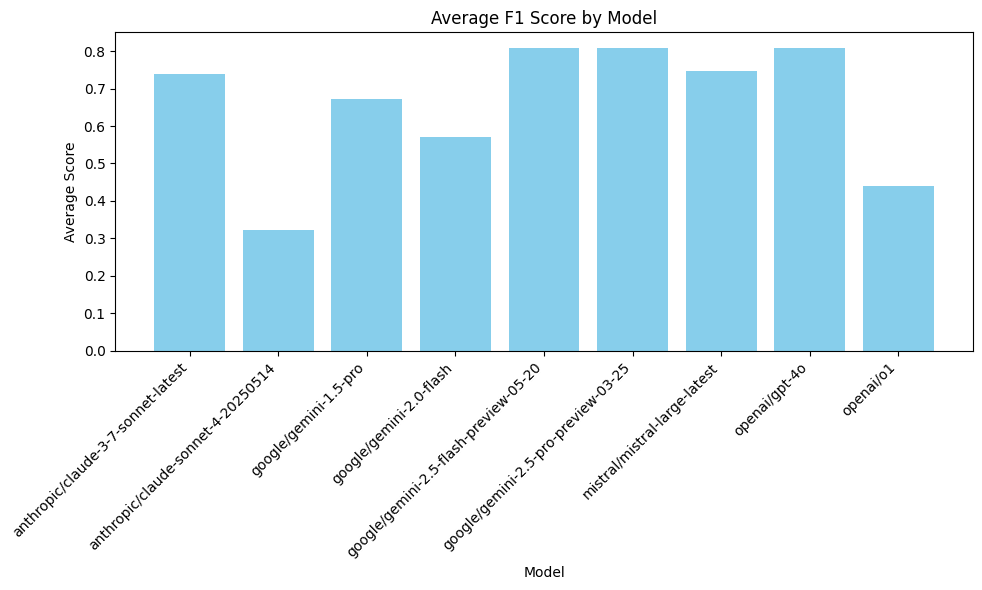

In [53]:
import matplotlib.pyplot as plt

# Grouping the data by model and calculating the mean score for each model
model_scores = df.groupby('model')['score'].mean().reset_index()

# Plotting the bar plot
plt.figure(figsize=(10, 6))
plt.bar(model_scores['model'], model_scores['score'], color='skyblue')
plt.title('Average F1 Score by Model')
plt.xlabel('Model')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')  # Rotate model names for better readability
plt.tight_layout()
plt.show()